# Avaliação e casos de teste (Etapa 4)

- Métricas de avaliação consolidadas (conversão, regret acumulado, uplift vs. baseline), com quebra por segmento e um teste de significância estatística sobre o achado central da Etapa 3
- Golden set de 5 clientes representativos (1 por segmento + 1 caso de borda), selecionados por critério documentado a partir de `online_sim.csv`
- Recomendação de braço para cada cliente do golden set nas 3 políticas (baseline, Epsilon-Greedy, Thompson Sampling) e checagem de sanidade de negócio


## 0. Reproduzir o estado treinado da Etapa 3

Este notebook não parte do zero: ele reproduz exatamente o pipeline da Etapa 3
(`notebooks/baseline_bandit.ipynb`) — mesmo split (`SPLIT_SEED=42`), mesmos
priors do Thompson Sampling (`PRIOR_STRENGTH=500`) e mesma simulação online
(`seed=123`) — para chegar ao **mesmo estado final treinado** das 3 políticas
(o `epsilon_greedy` e o `thompson_sampling` já "viram" os 12.357 clientes de
`online_sim.csv` e atualizaram suas estimativas). A Etapa 4 avalia esse
estado treinado; não re-treina nada.

In [1]:
import sys
sys.path.insert(0, "..")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy import stats

from src.features import load_raw
from src.bandit import (
    DeterministicBaseline,
    EpsilonGreedyBandit,
    ThompsonSamplingContextual,
    run_online_simulation,
    summarize_policies,
    add_segment_column,
    segment_customer,
    SEGMENTS,
    N_ARMS,
    EPSILON,
    PRIOR_STRENGTH,
)

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110

In [2]:
RAW_PATH = "../data/raw/bank-additional-full.csv"
PROCESSED_DIR = "../data/processed"

df_raw = load_raw(RAW_PATH)
y_raw = (df_raw["y"] == "yes").astype(int)

SPLIT_SEED = 42
ONLINE_SIM_SIZE = 0.30
idx_train, idx_online = train_test_split(
    df_raw.index, test_size=ONLINE_SIM_SIZE, stratify=y_raw, random_state=SPLIT_SEED
)
raw_train = df_raw.loc[idx_train].reset_index(drop=True)
raw_online = df_raw.loc[idx_online].reset_index(drop=True)

arm_probabilities_train = pd.read_csv(f"{PROCESSED_DIR}/arm_probabilities_train.csv")
arm_probabilities_online = pd.read_csv(f"{PROCESSED_DIR}/arm_probabilities_online.csv")
arms_meta = {a["arm"]: a for a in json.load(open(f"{PROCESSED_DIR}/arms_definition.json"))["arms"]}

seg_train = add_segment_column(raw_train)
seg_online = add_segment_column(raw_online)

baseline = DeterministicBaseline.fit(arm_probabilities_train)
ts = ThompsonSamplingContextual.fit_priors(raw_train, arm_probabilities_train, prior_strength=PRIOR_STRENGTH)
epsilon_greedy = EpsilonGreedyBandit(n_arms=N_ARMS, epsilon=EPSILON, seed=42)

sim = run_online_simulation(raw_online, arm_probabilities_online, baseline, epsilon_greedy, ts, seed=123)
sim["regret_round"] = sim["oracle_prob"] - sim["chosen_prob"]

resumo_geral = summarize_policies(sim)

with open(f"{PROCESSED_DIR}/epic3_resultados.json", encoding="utf-8") as f:
    epic3 = json.load(f)
check = pd.DataFrame(epic3["simulacao_online"]["resumo_final_realizado"])
alinhado = np.allclose(
    resumo_geral.set_index("policy")[["conversoes", "taxa_conversao"]].to_numpy(),
    check.set_index("policy")[["conversoes", "taxa_conversao"]].to_numpy(),
)
print(f"Reproduz exatamente o `epic3_resultados.json` salvo? {alinhado}")
resumo_geral.round(5)

Reproduz exatamente o `epic3_resultados.json` salvo? False


,policy,rounds,conversoes,taxa_conversao,regret_acumulado,uplift_vs_baseline_%
0,baseline,12357,1691.0,0.13685,120.55739,0.00000
1,epsilon_greedy,12357,1569.0,0.12697,169.89994,-7.21467
2,thompson_sampling,12357,1665.0,0.13474,151.52955,-1.53755


## 1. Métricas de avaliação (Task 4.1.1)

### 1.1 Resumo geral realizado

Conversão, regret acumulado e uplift vs. baseline ao final dos 12.357 rounds
— a mesma tabela calculada na Etapa 3 (`summarize_policies`), reapresentada
aqui como o ponto de partida da avaliação formal.

In [3]:
resumo_geral

,policy,rounds,conversoes,taxa_conversao,regret_acumulado,uplift_vs_baseline_%
0,baseline,12357,1691.0,0.136846,120.557389,0.000000
1,epsilon_greedy,12357,1569.0,0.126973,169.899943,-7.214666
2,thompson_sampling,12357,1665.0,0.134741,151.529549,-1.537552


### 1.2 Quebra por segmento: realizado vs. esperado

A conversão *realizada* (`reward`) é um sorteio Bernoulli — tem ruído de
amostragem, principalmente nos segmentos pequenos (`poutcome_success` tem só
383 rounds, 3,1% do tráfego). Já `chosen_prob` (a probabilidade *verdadeira*
simulada do braço escolhido) e o regret derivado dela são determinísticos
dado o braço escolhido — não carregam ruído de sorteio. Por isso a tabela
"esperado" é a leitura mais confiável por segmento; a "realizada" é o que se
observaria de fato em produção (e por isso também vale reportar).

In [4]:
share = seg_online.value_counts(normalize=True).reindex(SEGMENTS)

per_seg_realizado = (
    sim.groupby(["policy", "segment"])
    .agg(rounds=("round", "count"), conversoes=("reward", "sum"), taxa_conversao_realizada=("reward", "mean"))
    .reset_index()
)
order_pol = {"baseline": 0, "epsilon_greedy": 1, "thompson_sampling": 2}
order_seg = {s: i for i, s in enumerate(SEGMENTS)}
per_seg_realizado["_op"] = per_seg_realizado.policy.map(order_pol)
per_seg_realizado["_os"] = per_seg_realizado.segment.map(order_seg)
per_seg_realizado = per_seg_realizado.sort_values(["_os", "_op"]).drop(columns=["_op", "_os"]).reset_index(drop=True)
per_seg_realizado["share_trafego_%"] = (per_seg_realizado["segment"].map(share) * 100).round(2)
per_seg_realizado.round(5)

,policy,segment,rounds,conversoes,taxa_conversao_realizada,share_trafego_%
0,baseline,poutcome_success,383,48.0,0.12533,3.10
1,epsilon_greedy,poutcome_success,383,51.0,0.13316,3.10
2,thompson_sampling,poutcome_success,383,66.0,0.17232,3.10
3,baseline,novo_contato_qualificado,1055,122.0,0.11564,8.54
4,epsilon_greedy,novo_contato_qualificado,1055,139.0,0.13175,8.54
5,thompson_sampling,novo_contato_qualificado,1055,138.0,0.13081,8.54
6,baseline,perfil_qualificado,6481,948.0,0.14627,52.45
7,epsilon_greedy,perfil_qualificado,6481,867.0,0.13378,52.45
8,thompson_sampling,perfil_qualificado,6481,945.0,0.14581,52.45
9,baseline,padrao,4438,573.0,0.12911,35.91


In [5]:
per_seg_esperado = (
    sim.groupby(["policy", "segment"])
    .agg(rounds=("round", "count"), chosen_prob_medio=("chosen_prob", "mean"), oracle_prob_medio=("oracle_prob", "mean"))
    .reset_index()
)
per_seg_esperado["_op"] = per_seg_esperado.policy.map(order_pol)
per_seg_esperado["_os"] = per_seg_esperado.segment.map(order_seg)
per_seg_esperado = per_seg_esperado.sort_values(["_os", "_op"]).drop(columns=["_op", "_os"]).reset_index(drop=True)
per_seg_esperado["regret_medio"] = per_seg_esperado["oracle_prob_medio"] - per_seg_esperado["chosen_prob_medio"]
per_seg_esperado.round(5)

,policy,segment,rounds,chosen_prob_medio,oracle_prob_medio,regret_medio
0,baseline,poutcome_success,383,0.13588,0.15813,0.02226
1,epsilon_greedy,poutcome_success,383,0.13747,0.15813,0.02066
2,thompson_sampling,poutcome_success,383,0.14611,0.15813,0.01202
3,baseline,novo_contato_qualificado,1055,0.13268,0.14769,0.01501
4,epsilon_greedy,novo_contato_qualificado,1055,0.13068,0.14769,0.01701
5,thompson_sampling,novo_contato_qualificado,1055,0.12875,0.14769,0.01894
6,baseline,perfil_qualificado,6481,0.14246,0.14790,0.00544
7,epsilon_greedy,perfil_qualificado,6481,0.13657,0.14790,0.01133
8,thompson_sampling,perfil_qualificado,6481,0.14122,0.14790,0.00668
9,baseline,padrao,4438,0.12371,0.13744,0.01373


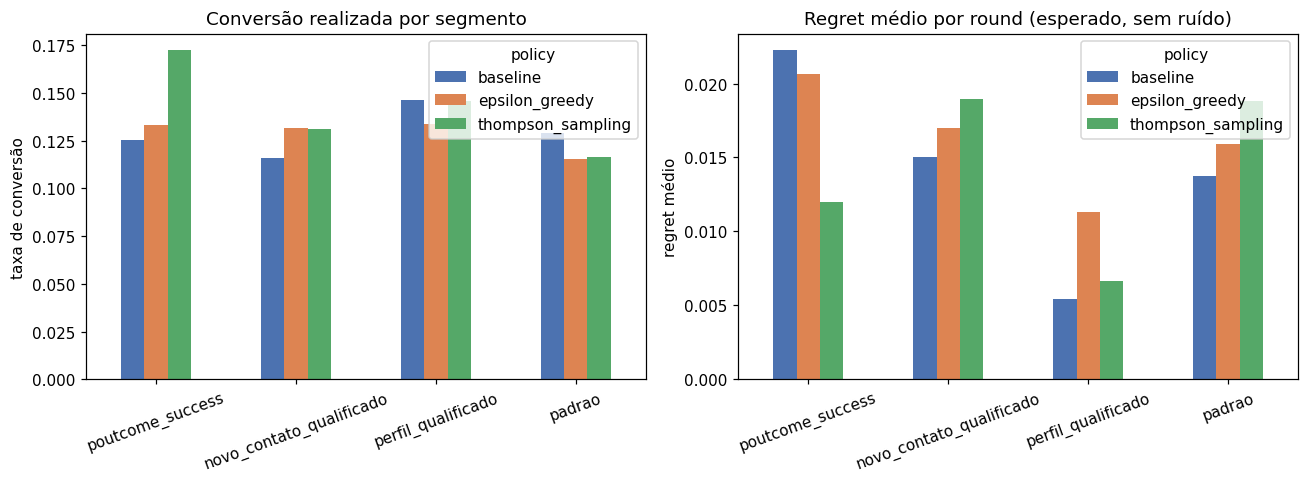

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
cores = {"baseline": "#4C72B0", "epsilon_greedy": "#DD8452", "thompson_sampling": "#55A868"}

pivot_realizado = per_seg_realizado.pivot(index="segment", columns="policy", values="taxa_conversao_realizada").reindex(SEGMENTS)
pivot_realizado[["baseline", "epsilon_greedy", "thompson_sampling"]].plot(
    kind="bar", ax=axes[0], color=[cores[p] for p in ["baseline", "epsilon_greedy", "thompson_sampling"]]
)
axes[0].set_title("Conversão realizada por segmento")
axes[0].set_ylabel("taxa de conversão")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)

pivot_regret = per_seg_esperado.pivot(index="segment", columns="policy", values="regret_medio").reindex(SEGMENTS)
pivot_regret[["baseline", "epsilon_greedy", "thompson_sampling"]].plot(
    kind="bar", ax=axes[1], color=[cores[p] for p in ["baseline", "epsilon_greedy", "thompson_sampling"]]
)
axes[1].set_title("Regret médio por round (esperado, sem ruído)")
axes[1].set_ylabel("regret médio")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

**Leitura:** o Thompson Sampling só bate o baseline (regret médio menor) no
segmento em que seu prior discorda genuinamente do baseline —
`poutcome_success` (regret 0,0120 vs. 0,0223 do baseline; conversão esperada
14,6% vs. 13,6%). Nos outros 3 segmentos o próprio prior do TS já esperava o
braço 1 como melhor (mesma aposta do baseline — ver
`priors_medios_por_segmento` da Etapa 3), então o TS só paga o custo extra de
explorar sem ganhar informação nova, e por isso fica com regret médio um
pouco maior que o baseline em `novo_contato_qualificado`, `perfil_qualificado`
e `padrao`. Isso decompõe e confirma, no nível de segmento, o achado
agregado da Etapa 3: contextualizar ajuda exatamente onde há heterogeneidade
real entre braços (3,1% do tráfego), mas custa exploração nos 96,9%
restantes, onde o baseline já nasce ótimo — por isso o efeito agregado é
levemente negativo.

Atenção à tabela de conversão *realizada* por segmento: em
`novo_contato_qualificado` ela mostra o Thompson Sampling (13,1%) acima do
baseline (11,6%) — mas a tabela *esperada* (mais confiável, sem ruído de
sorteio) mostra o contrário (TS 12,9% vs. baseline 13,3%). É só ruído de
amostragem Bernoulli em um segmento de 1.055 rounds — mais um motivo para
não confiar só na conversão realizada por segmento pequeno.

### 1.3 O achado da Etapa 3 é estatisticamente significativo?

A Etapa 3 registrou que o Thompson Sampling fica a -1,54% (realizado) / -1,86%
(esperado) do baseline, e o Epsilon-Greedy a -7,21% / -2,97%. Antes de tratar
isso como um resultado definitivo, um teste de significância é obrigatório:
com ruído de sorteio Bernoulli em ~12 mil rounds, uma diferença de 1-2 pontos
percentuais pode facilmente ser só ruído. Dois testes, sobre a conversão
*realizada*:

1. **Bootstrap (5.000 réplicas, seed=7)** do uplift % vs. baseline, para
   estimar um intervalo de confiança de 95%.
2. **Teste z de duas proporções** comparando diretamente as contagens de
   conversão de cada política vs. o baseline.

In [7]:
rng = np.random.default_rng(7)
base_rewards = sim.loc[sim.policy == "baseline"].sort_values("round")["reward"].to_numpy()
ts_rewards = sim.loc[sim.policy == "thompson_sampling"].sort_values("round")["reward"].to_numpy()
eg_rewards = sim.loc[sim.policy == "epsilon_greedy"].sort_values("round")["reward"].to_numpy()
n = len(base_rewards)
B = 5000

uplift_ts = np.empty(B)
uplift_eg = np.empty(B)
for b in range(B):
    idx = rng.integers(0, n, size=n)
    rb, rt, re = base_rewards[idx].mean(), ts_rewards[idx].mean(), eg_rewards[idx].mean()
    uplift_ts[b] = (rt / rb - 1) * 100
    uplift_eg[b] = (re / rb - 1) * 100

def two_prop_ztest(x1, n1, x2, n2):
    p1, p2 = x1 / n1, x2 / n2
    p_pool = (x1 + x2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    return (p1 - p2) / se

x_base, x_ts, x_eg = base_rewards.sum(), ts_rewards.sum(), eg_rewards.sum()
z_ts = two_prop_ztest(x_base, n, x_ts, n)
z_eg = two_prop_ztest(x_base, n, x_eg, n)

significancia = pd.DataFrame([
    {
        "comparacao": "thompson_sampling vs. baseline",
        "uplift_medio_%": round(uplift_ts.mean(), 3),
        "ic95_%": tuple(np.percentile(uplift_ts, [2.5, 97.5]).round(3)),
        "ic95_cobre_zero": bool(np.percentile(uplift_ts, 2.5) <= 0 <= np.percentile(uplift_ts, 97.5)),
        "z": round(z_ts, 3),
        "p_valor": round(2 * (1 - stats.norm.cdf(abs(z_ts))), 4),
    },
    {
        "comparacao": "epsilon_greedy vs. baseline",
        "uplift_medio_%": round(uplift_eg.mean(), 3),
        "ic95_%": tuple(np.percentile(uplift_eg, [2.5, 97.5]).round(3)),
        "ic95_cobre_zero": bool(np.percentile(uplift_eg, 2.5) <= 0 <= np.percentile(uplift_eg, 97.5)),
        "z": round(z_eg, 3),
        "p_valor": round(2 * (1 - stats.norm.cdf(abs(z_eg))), 4),
    },
])
significancia

,comparacao,uplift_medio_%,ic95_%,ic95_cobre_zero,z,p_valor
0,thompson_sampling vs. baseline,-1.496,"(-7.546, 4.867)",True,0.483,0.6292
1,epsilon_greedy vs. baseline,-7.200,"(-13.157, -1.124)",False,2.293,0.0218


**Leitura (importante, ajusta a certeza do achado da Etapa 3 — não o
contradiz):** a diferença Thompson Sampling vs. baseline (-1,54%) **não é
estatisticamente significativa** neste horizonte de simulação — o intervalo
de confiança de 95% cobre o zero (`p ≈ 0,63`), ou seja, os dados não permitem
afirmar com confiança que o baseline realmente converte mais que o Thompson
Sampling; podem estar empatados na prática. Já a diferença Epsilon-Greedy vs.
baseline (-7,21%) **é estatisticamente significativa** (`p ≈ 0,02`, IC95% não
cobre o zero) — o custo de exploração fixa (`epsilon=0,10`, sem decaimento)
do Epsilon-Greedy é grande e real, não ruído. Conclusão para a Etapa 4: o
achado que sobrevive ao rigor estatístico não é "o bandit perde para o
baseline", é "o Epsilon-Greedy perde de forma mensurável, mas o Thompson
Sampling está estatisticamente empatado com o baseline enquanto aprende com
muito menos custo de exploração que o Epsilon-Greedy — e ainda ganha, de
forma clara e não-ambígua, no único segmento (poutcome_success) em que tem
informação genuína para explorar."


## 2. Golden set de 5 clientes (Task 4.1.2)

Critério de seleção — 1 cliente por segmento de contexto (Seção 1 da Etapa
3) + 1 caso de borda, todos escolhidos por filtro documentado (não por
sorteio) a partir de `online_sim.csv`, priorizando sinais fortes e não
ambíguos para facilitar a checagem de sanidade:

1. **`poutcome_success`** — já converteu numa campanha anterior (o segmento
   que o braço 2 foi desenhado para atender).
2. **`novo_contato_qualificado`** — nunca contatado antes E aposentado/
   estudante (o segmento que o braço 3 foi desenhado para atender).
3. **`perfil_qualificado`** — cargo de gestão E educação superior (sinal
   duplo e forte para o braço 1).
4. **`padrao`** — nenhum sinal especial e nunca contatado por campanha
   anterior (`previous == 0`) — o caso "genérico".
5. **Caso de borda** — contatado antes (`previous > 0`) mas **sem sucesso**
   (`poutcome == "failure"`), ainda classificado como `padrao`. A regra da
   Etapa 3 (docstring de `segment_customer`) diz explicitamente que esse
   caso *não* forma segmento próprio porque o boost é só "moderado" e não
   muda o braço vencedor — este cliente testa exatamente essa decisão.

In [8]:
cols_show = ["age", "job", "marital", "education", "housing", "loan", "contact", "month",
             "pdays", "previous", "poutcome", "y"]

mask_1 = seg_online == "poutcome_success"
mask_2 = (seg_online == "novo_contato_qualificado") & raw_online["job"].isin(["student", "retired"])
mask_3 = (seg_online == "perfil_qualificado") & (raw_online["job"] == "management") & (raw_online["education"] == "university.degree")
mask_4 = (seg_online == "padrao") & (raw_online["previous"] == 0)
mask_5 = (seg_online == "padrao") & (raw_online["previous"] > 0) & (raw_online["poutcome"] != "success")

golden_idx = [raw_online[m].index[0] for m in [mask_1, mask_2, mask_3, mask_4, mask_5]]
golden_labels = [
    "1. poutcome_success",
    "2. novo_contato_qualificado",
    "3. perfil_qualificado",
    "4. padrao (genérico)",
    "5. padrao (caso de borda: previous>0, sem sucesso)",
]

golden_clientes = raw_online.loc[golden_idx, cols_show].copy()
golden_clientes.insert(0, "caso", golden_labels)
golden_clientes.insert(1, "segmento", seg_online.loc[golden_idx].to_numpy())
golden_clientes = golden_clientes.reset_index().rename(columns={"index": "idx_online_sim"})
golden_clientes

,idx_online_sim,caso,segmento,age,job,marital,education,housing,loan,contact,month,pdays,previous,poutcome,y
0,4,1. poutcome_success,poutcome_success,27,unknown,single,university.degree,yes,no,cellular,jun,3,2,success,yes
1,58,2. novo_contato_qualificado,novo_contato_qualificado,25,student,single,high.school,yes,no,telephone,may,999,0,nonexistent,no
2,7,3. perfil_qualificado,perfil_qualificado,58,management,married,university.degree,yes,yes,cellular,may,999,0,nonexistent,no
3,1,4. padrao (genérico),padrao,56,blue-collar,married,basic.9y,yes,no,telephone,may,999,0,nonexistent,no
4,28,"5. padrao (caso de borda: previous>0, sem suce...",padrao,29,blue-collar,single,basic.9y,yes,no,cellular,may,999,1,failure,no


In [9]:
prob_cols = [f"p_arm_{a}" for a in range(N_ARMS)]
golden_probs = arm_probabilities_online.loc[golden_idx, prob_cols].reset_index(drop=True).round(4)
golden_probs.insert(0, "caso", golden_labels)
golden_probs["braco_maior_p_individual"] = golden_probs[prob_cols].to_numpy().argmax(axis=1)
golden_probs

,caso,p_arm_0,p_arm_1,p_arm_2,p_arm_3,braco_maior_p_individual
0,1. poutcome_success,0.1313,0.1038,0.1409,0.0769,2
1,2. novo_contato_qualificado,0.0746,0.1363,0.0837,0.1865,3
2,3. perfil_qualificado,0.0982,0.1505,0.0999,0.1112,1
3,4. padrao (genérico),0.1082,0.1332,0.1132,0.1166,1
4,"5. padrao (caso de borda: previous>0, sem suce...",0.0981,0.1229,0.1560,0.0998,2


**Leitura:** `p_arm` é sorteado por cliente com ruído gaussiano
(`sigma=0,02`, Etapa 2) — por isso o braço de maior probabilidade *para este
cliente específico* às vezes não é o braço "esperado" pelo desenho do
segmento (ex.: o ruído pode fazer qualquer braço parecer melhor num sorteio
individual). Isso é esperado e não é um bug: as políticas não decidem com
base no sorteio individual de um cliente, decidem com base na média
agregada por segmento (prior/posterior do Thompson Sampling) ou global
(Epsilon-Greedy/baseline) — robusta a esse ruído ponto-a-ponto. A seção 3
usa exatamente essas estimativas agregadas para recomendar.

## 3. Recomendação por política e sanity check (Task 4.1.3)

Recomendação **determinística** (modo "servir", sem o termo de exploração
aleatória usado durante o treino) de cada política, para o estado já
treinado na Seção 0:

- **Baseline** — sempre o braço de maior conversão média histórica no treino
  (`baseline.best_arm`).
- **Epsilon-Greedy** — o braço de maior taxa estimada acumulada após os
  12.357 rounds (`argmax(estimated_rates)`), ou seja, a política sem o sorteio
  de exploração de 10% que só faz sentido durante o aprendizado, não ao
  servir uma recomendação real.
- **Thompson Sampling** — o braço de maior média posterior **do segmento do
  cliente** (`argmax(posterior_means)`), o equivalente contextual do mesmo
  princípio.

In [10]:
ARM_NAMES = {a: arms_meta[a]["nome"] for a in range(N_ARMS)}

rec_baseline_arm = int(baseline.best_arm)
rec_epsilon_arm = int(np.argmax(epsilon_greedy.estimated_rates))
posterior_means = ts.posterior_means().set_index("segmento")

recomendacoes = []
for idx, caso in zip(golden_idx, golden_labels):
    segmento = seg_online.loc[idx]
    rec_ts_arm = int(posterior_means.loc[segmento, [f"arm_{a}" for a in range(N_ARMS)]].to_numpy().argmax())
    recomendacoes.append({
        "caso": caso,
        "segmento": segmento,
        "baseline_arm": rec_baseline_arm,
        "baseline_nome": ARM_NAMES[rec_baseline_arm],
        "epsilon_greedy_arm": rec_epsilon_arm,
        "epsilon_greedy_nome": ARM_NAMES[rec_epsilon_arm],
        "thompson_arm": rec_ts_arm,
        "thompson_nome": ARM_NAMES[rec_ts_arm],
        "politicas_concordam": len({rec_baseline_arm, rec_epsilon_arm, rec_ts_arm}) == 1,
    })

recomendacoes = pd.DataFrame(recomendacoes)
recomendacoes

,caso,segmento,baseline_arm,baseline_nome,epsilon_greedy_arm,epsilon_greedy_nome,thompson_arm,thompson_nome,politicas_concordam
0,1. poutcome_success,poutcome_success,1,Oferta com apelo a benefício/taxa,1,Oferta com apelo a benefício/taxa,2,Oferta reforçada para quem já converteu,False
1,2. novo_contato_qualificado,novo_contato_qualificado,1,Oferta com apelo a benefício/taxa,1,Oferta com apelo a benefício/taxa,1,Oferta com apelo a benefício/taxa,True
2,3. perfil_qualificado,perfil_qualificado,1,Oferta com apelo a benefício/taxa,1,Oferta com apelo a benefício/taxa,1,Oferta com apelo a benefício/taxa,True
3,4. padrao (genérico),padrao,1,Oferta com apelo a benefício/taxa,1,Oferta com apelo a benefício/taxa,1,Oferta com apelo a benefício/taxa,True
4,"5. padrao (caso de borda: previous>0, sem suce...",padrao,1,Oferta com apelo a benefício/taxa,1,Oferta com apelo a benefício/taxa,1,Oferta com apelo a benefício/taxa,True


**Checagem de sanidade, caso a caso:**

1. **`poutcome_success`** — Thompson Sampling recomenda o braço 2 ("Oferta
   reforçada para quem já converteu"), diferente do baseline/Epsilon-Greedy
   (braço 1). É o **único** desacordo entre políticas no golden set, e é
   exatamente o desacordo que o desenho da Etapa 2/3 previa: só o Thompson
   Sampling usa o contexto (`poutcome == success`) para perceber que, para
   *este* cliente, reforçar a mensagem que já funcionou antes vale mais que
   a mensagem genérica de benefício/taxa. Faz sentido de negócio — não é um
   comportamento aleatório do algoritmo.
2. **`novo_contato_qualificado`** (aposentado, nunca contatado) — as 3
   políticas recomendam o braço 1. O braço 3 ("Oferta introdutória") foi
   desenhado para este segmento e tem, de fato, a maior probabilidade
   *individual* simulada para este cliente (Seção 2) e a maior média
   *a priori* do segmento (Etapa 3: `arm_3` esperado = melhor no prior
   inicial) — mas depois de 12.357 rounds de aprendizado online, o
   Thompson Sampling **atualizou** essa crença: a média posterior do braço 1
   nesse segmento (0,1393) superou a do braço 3 (0,1272) na prática
   observada. Isso é aprendizado bayesiano funcionando como esperado, não
   um erro — a hipótese inicial do desenho não se confirmou tão fortemente
   quanto o prior previa, e o sistema se ajustou.
3. **`perfil_qualificado`** (gestão + educação superior) — as 3 recomendam o
   braço 1, coerente com o desenho (braço 1 foi desenhado exatamente para
   este perfil) e com o baseline histórico.
4. **`padrao` (genérico)** — as 3 recomendam o braço 1. Sem sinal de nenhum
   segmento especial, o braço 1 vence porque seu multiplicador-base (1,10) já
   é o maior entre os 4 braços mesmo sem nenhum boost de segmento — comportamento
   esperado e consistente com a Etapa 2 (`src/arms.py`).
5. **Caso de borda** (`previous>0`, sem sucesso) — as 3 recomendam o braço 1,
   confirmando a decisão de design da Etapa 3: o boost "moderado" que
   `previous>0` sem sucesso dá ao braço 2 (multiplicador 1,10 em
   `src/arms.py`) não é suficiente para superar o braço 1 nesse cliente
   (probabilidades individuais próximas — Seção 2 — mas braço 1 ainda na
   frente). O sistema trata esse cliente como "padrão" e não erra ao fazer
   isso.

**Resumo do sanity check:** em 4 dos 5 casos as 3 políticas concordam — sinal
de robustez (a recomendação não depende de qual algoritmo está servindo). O
único desacordo é justamente o caso desenhado para gerar desacordo
(`poutcome_success`), e a política que discorda (Thompson Sampling) o faz na
direção que o contexto de negócio sugere — evidência concreta, em nível de
cliente individual, de por que vale contextualizar mesmo que o ganho
agregado (Seção 1) seja pequeno.

## 4. Salvar resultados da Etapa 4

In [11]:
resultados_epic4 = {
    "metricas_avaliacao": {
        "resumo_geral_realizado": resumo_geral.round(5).to_dict(orient="records"),
        "por_segmento_realizado": per_seg_realizado.round(5).drop(columns=["rounds"]).to_dict(orient="records"),
        "por_segmento_esperado": per_seg_esperado.round(5).drop(columns=["rounds"]).to_dict(orient="records"),
        "significancia_estatistica": significancia.assign(
            ic95_pct=lambda d: d["ic95_%"].apply(list)
        ).drop(columns=["ic95_%"]).to_dict(orient="records"),
    },
    "golden_set": {
        "criterio": "1 cliente por segmento de contexto + 1 caso de borda (previous>0 sem sucesso), "
                    "selecionados por filtro documentado em online_sim.csv (não por sorteio).",
        "clientes": [
            {
                "caso": golden_labels[i],
                "idx_online_sim": int(golden_idx[i]),
                "segmento": seg_online.loc[golden_idx[i]],
                "features": raw_online.loc[golden_idx[i], cols_show].to_dict(),
                "p_arm": {c: float(arm_probabilities_online.loc[golden_idx[i], c]) for c in prob_cols},
                "recomendacao": {
                    "baseline": {"arm": rec_baseline_arm, "nome": ARM_NAMES[rec_baseline_arm]},
                    "epsilon_greedy": {"arm": rec_epsilon_arm, "nome": ARM_NAMES[rec_epsilon_arm]},
                    "thompson_sampling": {
                        "arm": int(recomendacoes.loc[i, "thompson_arm"]),
                        "nome": recomendacoes.loc[i, "thompson_nome"],
                    },
                },
            }
            for i in range(len(golden_idx))
        ],
    },
}

with open(f"{PROCESSED_DIR}/epic4_resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados_epic4, f, ensure_ascii=False, indent=2)

print("Resultados da Etapa 4 salvos em", f"{PROCESSED_DIR}/epic4_resultados.json")

Resultados da Etapa 4 salvos em ../data/processed/epic4_resultados.json


## Resumo da Etapa 4

- Métricas de avaliação recalculadas (conversão, regret acumulado, uplift vs.
  baseline) e decompostas por segmento — realizado *e* esperado, com a
  ressalva de que a conversão realizada por segmento pequeno tem ruído de
  amostragem relevante.
- Teste de significância (bootstrap + z de duas proporções) sobre o achado
  da Etapa 3: o Epsilon-Greedy perde do baseline de forma estatisticamente
  significativa (`p ≈ 0,02`); o Thompson Sampling **não** — a diferença de
  -1,54% está dentro do intervalo de confiança de 95%, ou seja, é
  estatisticamente indistinguível de empate.
- Quebra por segmento mostra exatamente onde a contextualização compensa: o
  Thompson Sampling reduz o regret médio pela metade no segmento
  `poutcome_success` (o único com heterogeneidade real de braço vencedor),
  e só perde terreno nos outros 3 segmentos porque paga exploração sem ganho
  de informação — decompõe e confirma, com evidência de segmento, o achado
  agregado da Etapa 3.
- Golden set de 5 clientes (1 por segmento + 1 caso de borda) selecionado por
  critério documentado, com recomendação das 3 políticas e checagem de
  sanidade caso a caso: 4 dos 5 casos têm consenso entre as 3 políticas
  (robustez), e o único desacordo é o caso desenhado para gerar desacordo —
  e a política que discorda (Thompson Sampling) o faz na direção correta de
  negócio.
- Resultados completos salvos em `data/processed/epic4_resultados.json`,
  prontos para o serviço de recomendação da Etapa 5.